In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

# Load Data

In [2]:
df = pd.read_csv('GISelA.csv')

# Load Dummies
df['Gap1'] = np.nan
df['Gap2'] = np.nan

# Prepare Data
cols = ['PatScoreArzt', 'PatScoreKI', 'Gap1', 'Exp1ScoreArzt', 'Exp1ScoreKI', 'Gap2', 'Exp2ScoreArzt', 'Exp2ScoreKI']
plot_data = df[cols]

# Make Figure 

In [3]:
colors = ['#FFFFFF', '#3290B3', 'none', '#FFFFFF', '#3290B3', 'none', '#FFFFFF', '#3290B3']

y_max_total = plot_data.max().max()
bracket_height = y_max_total * 0.02

significance_data = [
    (0, 1, slice(0, 2), '$P$<.001'),
    (3, 4, slice(3, 5), '$P$=.001'),
    (6, 7, slice(6, 8), '$P$=.145')
]

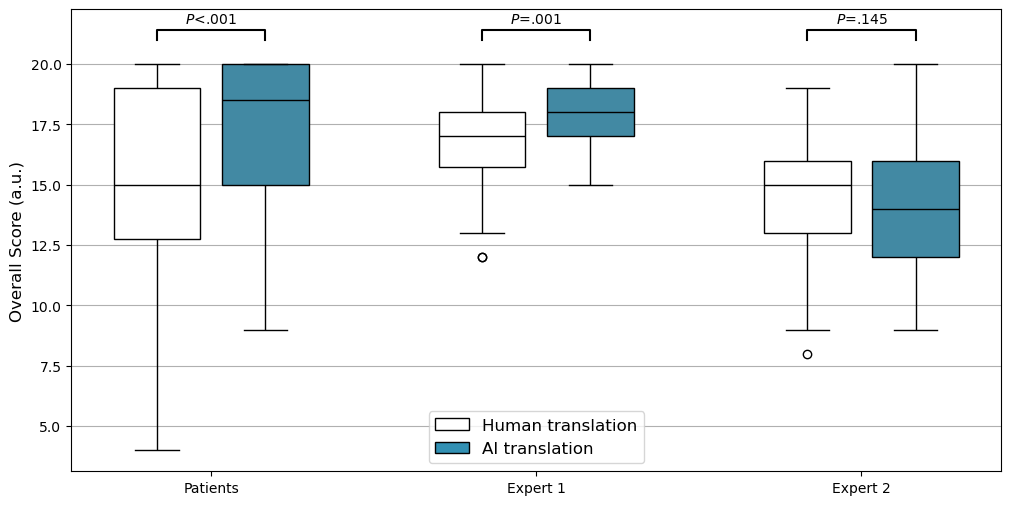

In [4]:
plt.figure(figsize=(12, 6))

# Plot Data
sns.boxplot(data=plot_data, palette=colors)
plt.ylabel('Overall Score (a.u.)', fontsize=12)
plt.xticks(ticks=[0.5, 3.5, 6.5], labels=['Patients', 'Expert 1', 'Expert 2'])

# Plot Significance Brackets
for x_start, x_end, col_slice, p_val in significance_data:
    
    # Calculate y_max for the specific pair
    y_max_group = plot_data.iloc[:, col_slice].max().max()
    bracket_y = y_max_group * 1.05

    # Draw the bracket
    plt.plot([x_start, x_start, x_end, x_end], 
             [bracket_y, bracket_y + bracket_height, bracket_y + bracket_height, bracket_y], 
             color='black', lw=1.5)

    # Add the p-value text
    plt.text((x_start + x_end) / 2, bracket_y + bracket_height + 0.15, 
             p_val, ha='center', va='bottom', fontsize=10)

# Make Legend
white_patch = mpatches.Patch(facecolor='#FFFFFF', label='Human translation', edgecolor='black', linewidth=1)
blue_patch = mpatches.Patch(facecolor='#3290B3', label='AI translation', edgecolor='black', linewidth=1)
plt.legend(handles=[white_patch, blue_patch], loc='lower center', fontsize=12)

plt.grid(True, axis='y')
plt.savefig('./figure1.png', bbox_inches='tight', dpi=400)

plt.show();
